> **Note:** The provided dataset contains country-level socio-economic indicators rather than customer records. Therefore, countries are treated as entities for segmentation and predictive modeling while implementing the required machine learning techniques.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('Country-data.csv')

In [3]:
df2= pd.read_csv('data-dictionary.csv')

In [4]:
df2.head(5)

,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...


In [5]:
df.head(5)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Data Cleaning

In [6]:
df.shape

(167, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [8]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [9]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

### Observation

- No missing values were found.
- No duplicate records were present.
- All numerical features have appropriate data types.
- The dataset is clean and ready for exploratory data analysis.

## Exploratory Data Analysis (EDA)


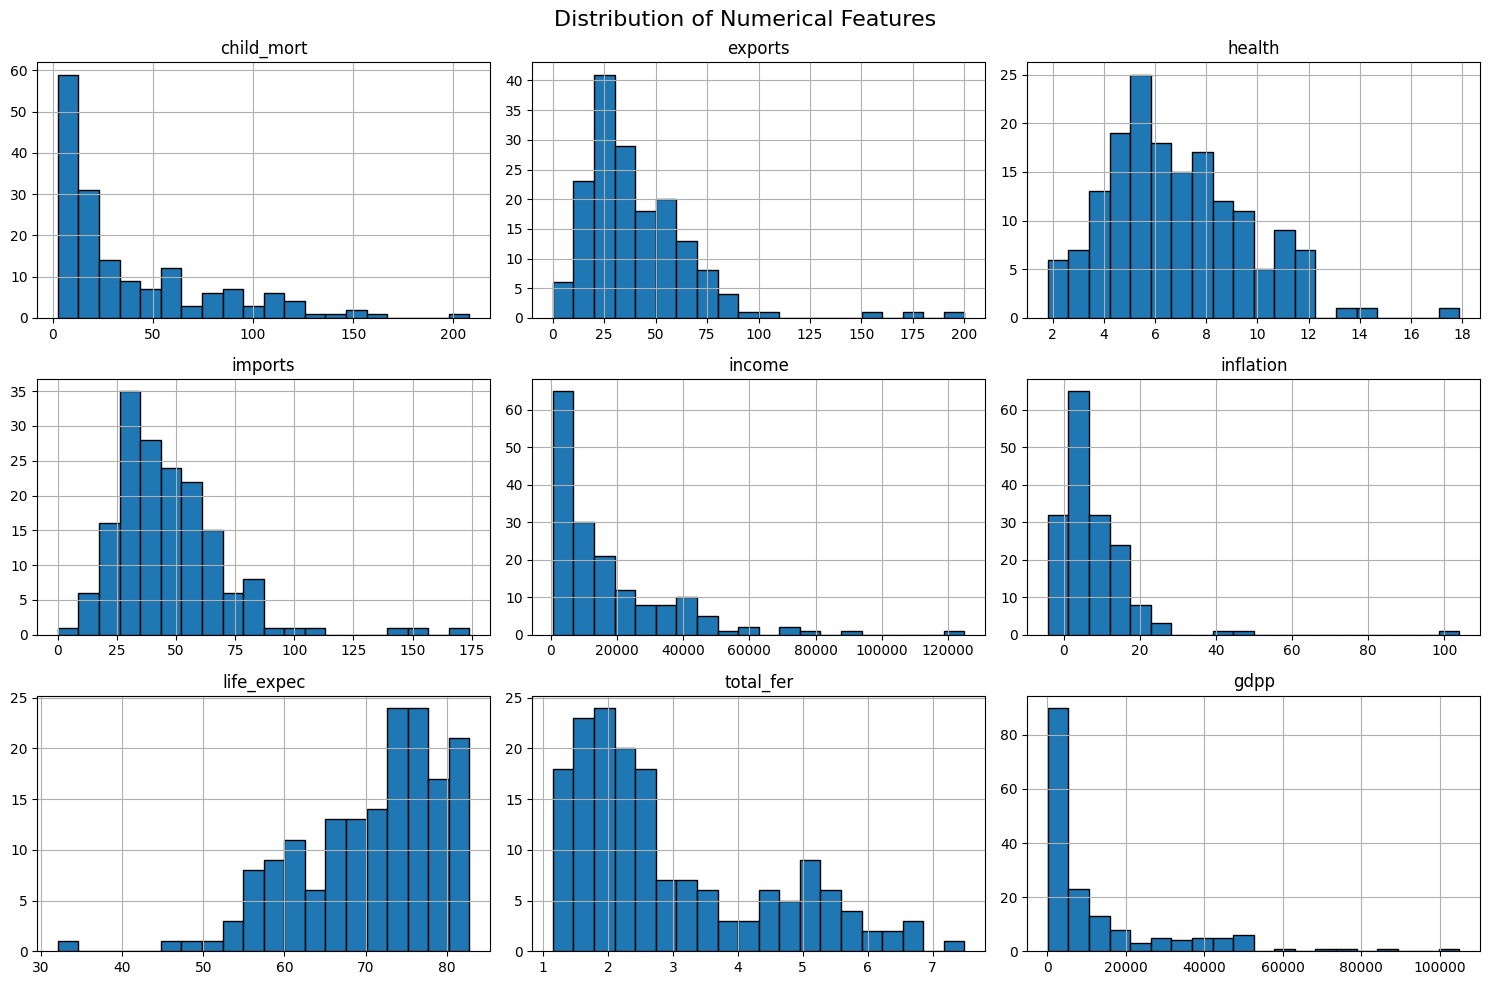

In [11]:
# Distribution of Numerical Features

df.hist(
    figsize=(15,10),
    bins=20,
    edgecolor="black"
)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()

plt.show()

### Observation

- Most numerical features are +ve skewed, with a large number of countries having relatively low values.
- Variables such as income, GDP, and child mortality contain a few countries with extremely high values.
- The distributions suggest that the dataset contains countries with diverse socio-economic conditions.

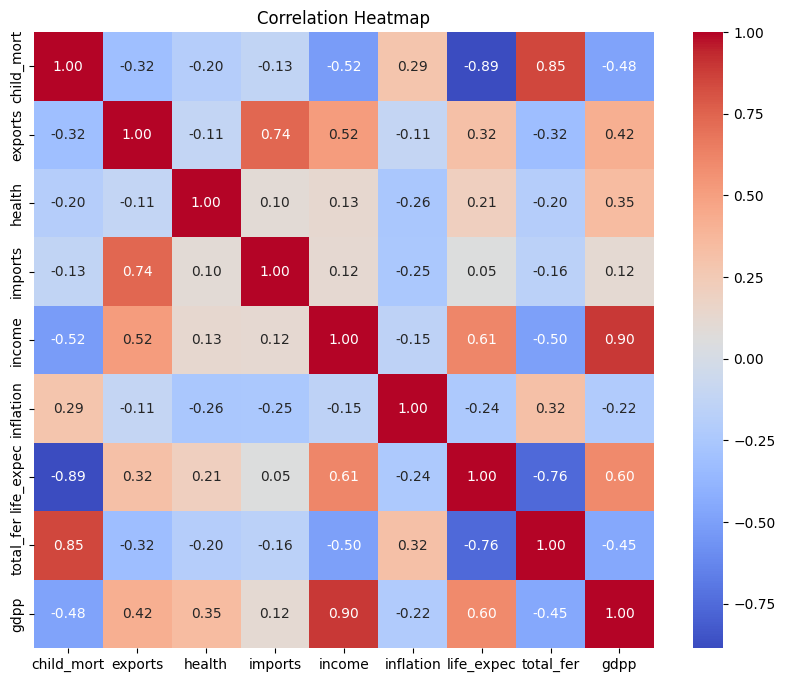

In [12]:
# Correlation Heatmap

plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")

plt.show()

### Observation

- Income and GDP per capita have a strong +ve correlation.
- Child mortality is strongly negatively correlated with life expectancy.
- Health expenditure shows a moderate positive relationship with life expectancy.
- These relationships indicate that economic and health-related indicators are closely connected.

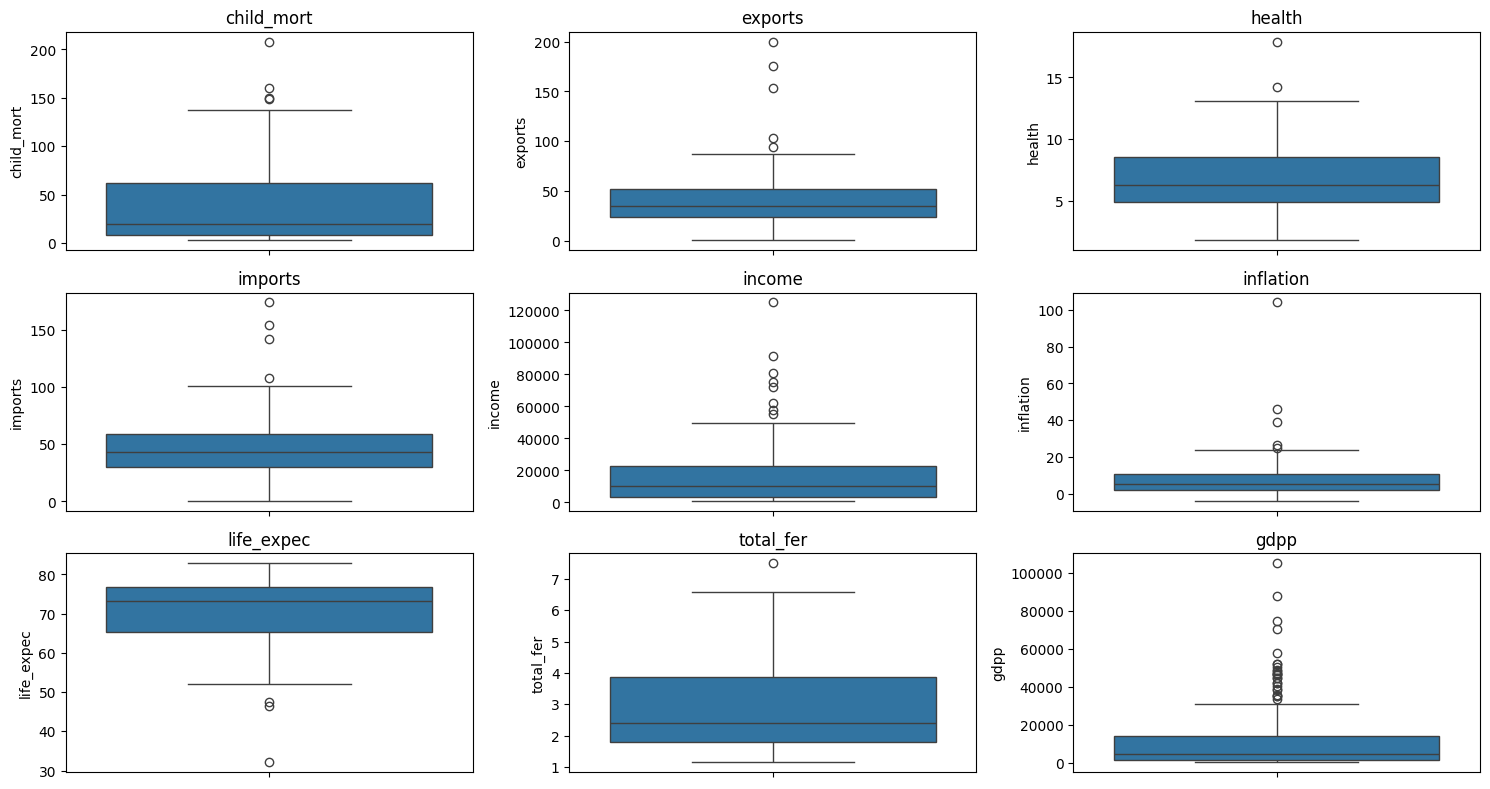

In [13]:
# Boxplots

numeric_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3,3,i)
    sns.boxplot(
        y=df[col]
    )
    plt.title(col)
plt.tight_layout()

plt.show()

### Observation

- Several numerical features contain outliers, particularly income, GDP, child mortality, and inflation.
- These outliers represent countries with exceptionally high or low socio-economic indicators.
- Since these are real-world observations, the outliers will be retained for clustering rather than removed.

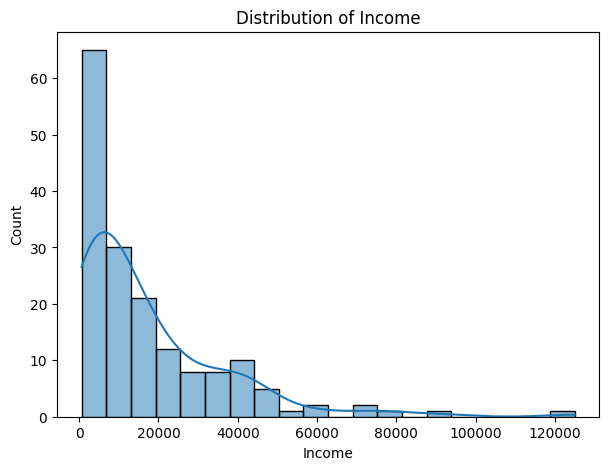

In [14]:
# Income Distribution

plt.figure(figsize=(7,5))
sns.histplot(
    df["income"],
    bins=20,
    kde=True
)
plt.title("Distribution of Income")
plt.xlabel("Income")
plt.ylabel("Count")

plt.show()

### Observation

- Most countries have relatively low income levels.
- The distribution is highly right-skewed, with only a few countries having very high income.
- This indicates a significant variation in economic conditions across countries.

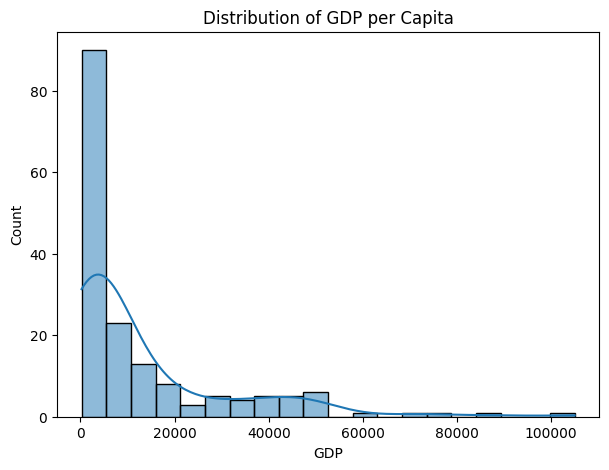

In [15]:
# GDP Distribution

plt.figure(figsize=(7,5))
sns.histplot(
    df["gdpp"],
    bins=20,
    kde=True
)
plt.title("Distribution of GDP per Capita")
plt.xlabel("GDP")
plt.ylabel("Count")

plt.show()

### Observation

- GDP per capita is concentrated at lower values for most countries.
- A few countries have exceptionally high GDP, resulting in a long right tail.
- The distribution highlights the economic disparity among countries.

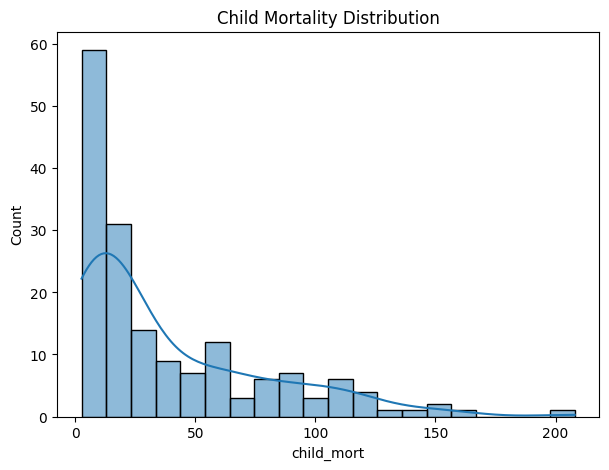

In [16]:
# Child Mortality Distribution

plt.figure(figsize=(7,5))
sns.histplot(
    df["child_mort"],
    bins=20,
    kde=True
)
plt.title("Child Mortality Distribution")

plt.show()

### Observation

- Most countries have relatively low child mortality rates.
- A small number of countries exhibit very high child mortality.
- The distribution is positively skewed, indicating unequal health outcomes across countries.

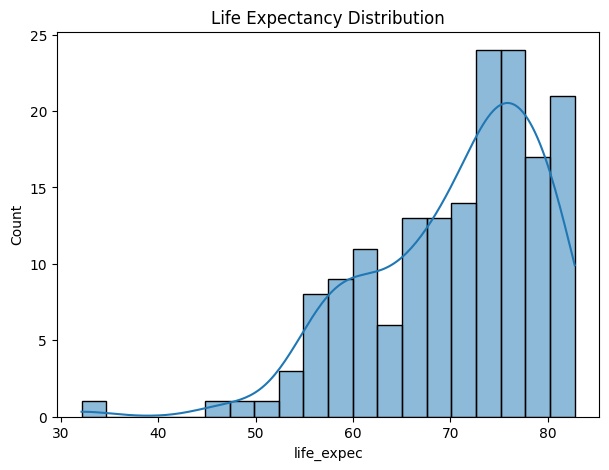

In [17]:
# Life Expectancy Distribution

plt.figure(figsize=(7,5))
sns.histplot(
    df["life_expec"],
    bins=20,
    kde=True
)
plt.title("Life Expectancy Distribution")

plt.show()

### Observation

- Most countries have life expectancy between 65 and 80 years.
- Only a few countries have very low life expectancy.
- The distribution is slightly left-skewed, suggesting that many countries have relatively high life expectancy.

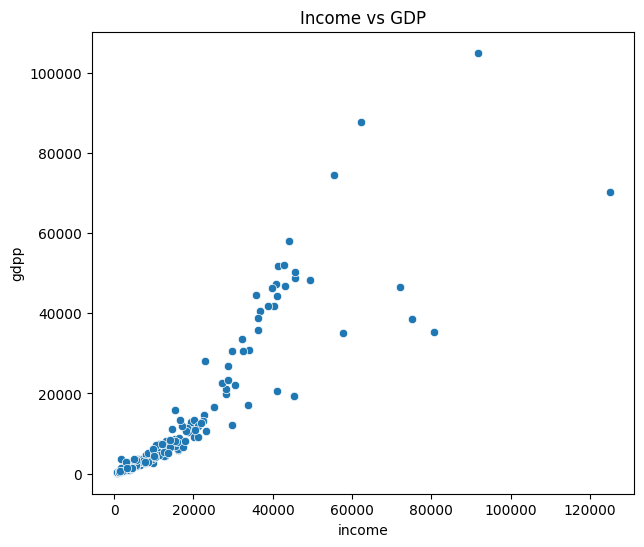

In [18]:
# Income vs GDP

plt.figure(figsize=(7,6))
sns.scatterplot(
    data=df,
    x="income",
    y="gdpp"
)
plt.title("Income vs GDP")

plt.show()

### Observation

- There is a strong positive relationship between income and GDP per capita.
- Countries with higher income generally have higher GDP per capita.
- This indicates that income is an important indicator of economic development.

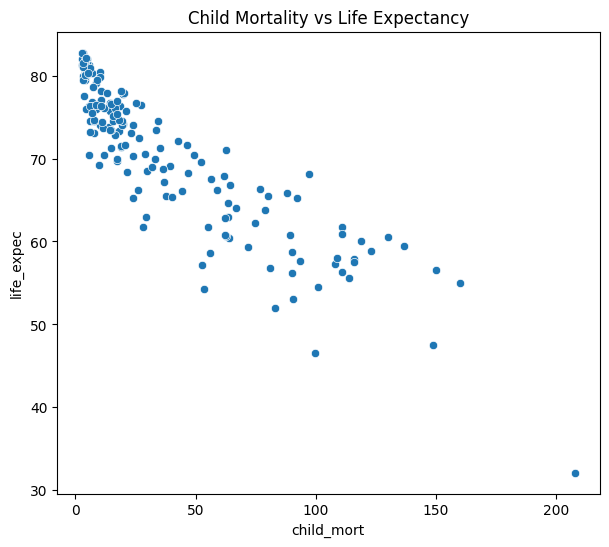

In [19]:
# Child Mortality vs Life Expectancy

plt.figure(figsize=(7,6))
sns.scatterplot(
    data=df,
    x="child_mort",
    y="life_expec"
)
plt.title("Child Mortality vs Life Expectancy")

plt.show()

### Observation

- A strong negative relationship exists between child mortality and life expectancy.
- Countries with higher child mortality generally have lower life expectancy.
- This relationship highlights the connection between healthcare quality and overall population well-being.

### EDA Summary

- The exploratory data analysis reveals significant differences in the socio-economic characteristics of countries. 
- Several features show skewed distributions and contain meaningful outliers, reflecting real-world economic diversity. 
- Strong relationships were observed between income and GDP, as well as between child mortality and life expectancy. 
- These insights indicate that the dataset is well-suited for clustering countries into meaningful groups based on their socio-economic profiles.

# Feature Scaling

Since K-Means and DBSCAN are distance-based algorithms, the numerical features are standardized using StandardScaler to ensure that each feature contributes equally during clustering.

In [20]:
from sklearn.preprocessing import StandardScaler

countries = df["country"]
X = df.drop("country", axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)
X_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


### Observation

- All numerical features have been standardized.
- Each feature now has approximately zero mean and unit variance.
- Scaling prevents variables with larger numerical ranges from dominating the clustering process.

# Elbow Method

The Elbow Method is used to determine the optimal number of clusters by analyzing the Within-Cluster Sum of Squares (WCSS) for different values of K.

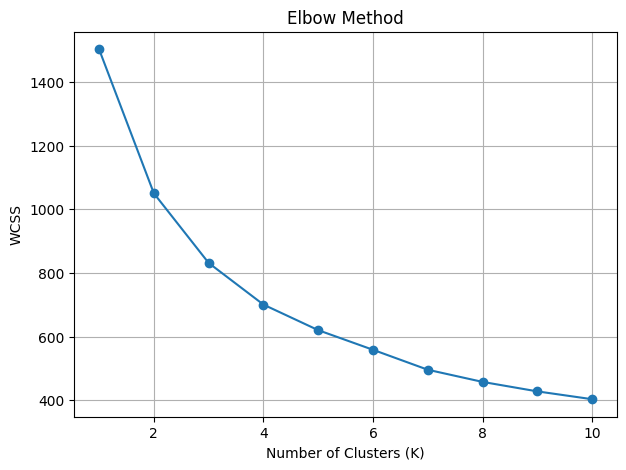

In [21]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

### Observation

- The WCSS decreases rapidly as the number of clusters increases from 1 to 4.
- After K = 4, the reduction in WCSS becomes gradual, indicating diminishing returns.
- Therefore, K = 4 is selected as the optimal number of clusters using the Elbow Method.

# Silhouette Score

The Silhouette Score measures how well-separated the clusters are. A higher score indicates better-defined and more compact clusters.

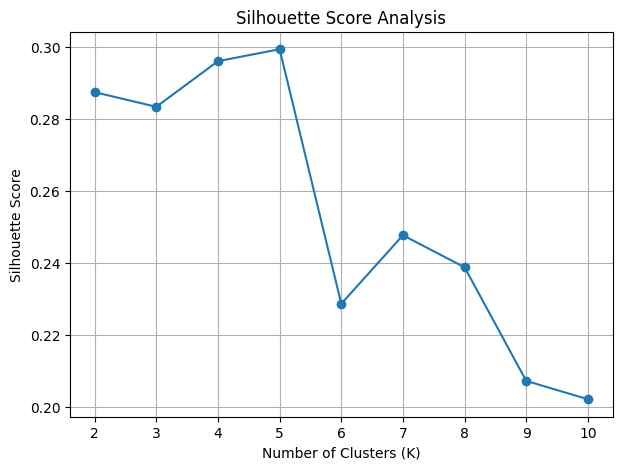

K=2  Silhouette Score=0.2874
K=3  Silhouette Score=0.2833
K=4  Silhouette Score=0.2960
K=5  Silhouette Score=0.2993
K=6  Silhouette Score=0.2287
K=7  Silhouette Score=0.2477
K=8  Silhouette Score=0.2388
K=9  Silhouette Score=0.2073
K=10  Silhouette Score=0.2022


In [22]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

plt.figure(figsize=(7,5))
plt.plot(
    range(2,11),
    scores,
    marker="o"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Analysis")

plt.grid(True)
plt.show()

for k, score in zip(range(2,11), scores):
    print(f"K={k}  Silhouette Score={score:.4f}")

### Observation

- The highest Silhouette Score was obtained at K = 5, while the Elbow Method suggested K = 4.
- Since the improvement in Silhouette Score is very small, K = 4 was selected to achieve a simpler and more interpretable clustering solution.

# K-Means Clustering

Apply the K-Means algorithm to segment countries into four groups based on their socio-economic indicators.

In [23]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


In [24]:
print(df["Cluster"].value_counts().sort_index())

Cluster
0    32
1    47
2    85
3     3
Name: count, dtype: int64


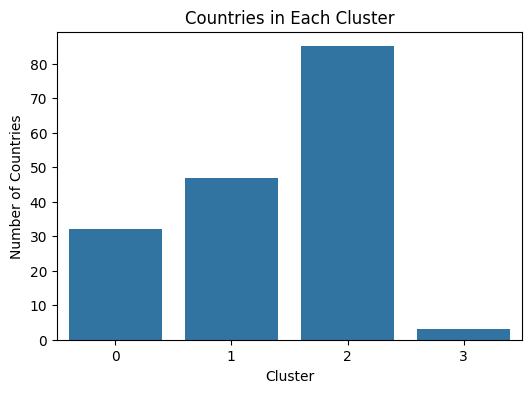

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Cluster",
    data=df
)
plt.title("Countries in Each Cluster")

plt.xlabel("Cluster")
plt.ylabel("Number of Countries")

plt.show()

# Cluster Analysis

In [26]:
# cluster summary
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.181250,46.118750,9.088437,40.584375,44021.875000,2.513844,80.081250,1.788437,42118.750000
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.690588,41.073988,6.197059,47.914893,12671.411765,7.609341,72.871765,2.300706,6519.552941
3,4.133333,176.000000,6.793333,156.666667,64033.333333,2.468000,81.433333,1.380000,57566.666667


In [27]:
# round val
cluster_summary.round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.18,46.12,9.09,40.58,44021.88,2.51,80.08,1.79,42118.75
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.69,41.07,6.20,47.91,12671.41,7.61,72.87,2.30,6519.55
3,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67


In [28]:
# no. of countries per cluster
df["Cluster"].value_counts().sort_index()

Cluster
0    32
1    47
2    85
3     3
Name: count, dtype: int64

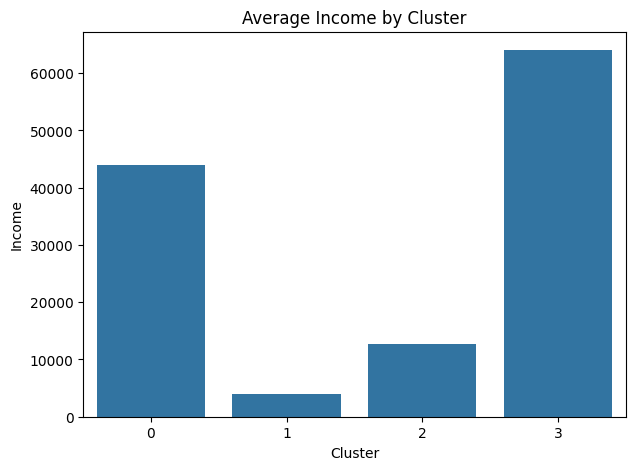

In [29]:
# avg income
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Cluster",
    y="income",
    estimator=np.mean,
    errorbar=None
)
plt.title("Average Income by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Income")

plt.show()

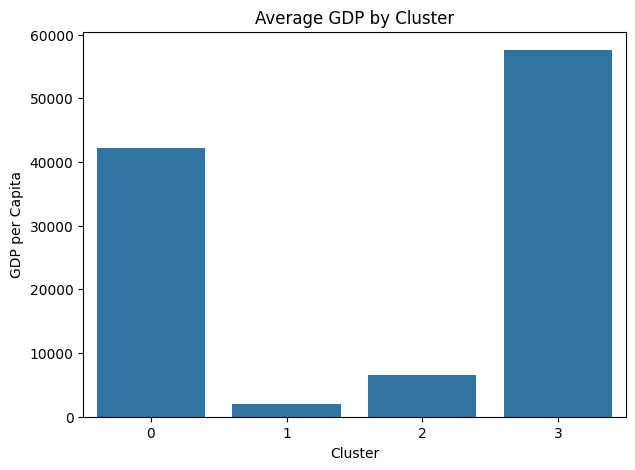

In [30]:
# avg gdp
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Cluster",
    y="gdpp",
    estimator=np.mean,
    errorbar=None
)
plt.title("Average GDP by Cluster")
plt.xlabel("Cluster")
plt.ylabel("GDP per Capita")

plt.show()

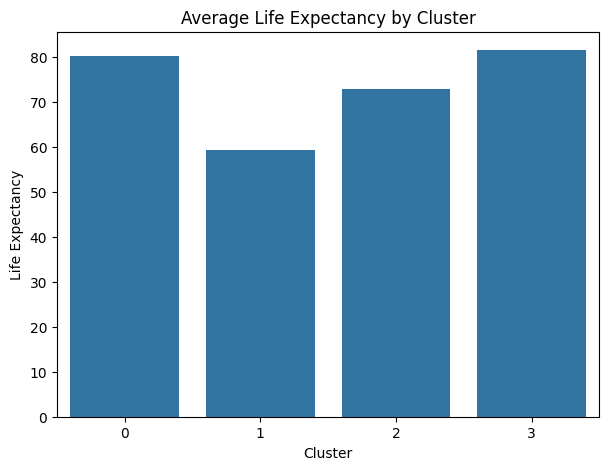

In [31]:
# avg life expectancy
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Cluster",
    y="life_expec",
    estimator=np.mean,
    errorbar=None
)
plt.title("Average Life Expectancy by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Life Expectancy")

plt.show()

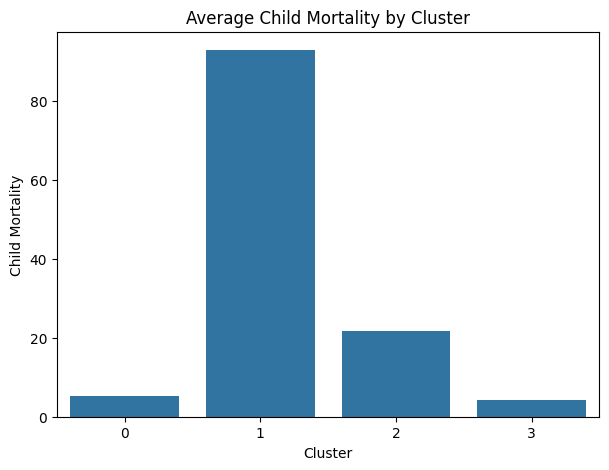

In [32]:
# avg child mortality
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Cluster",
    y="child_mort",
    estimator=np.mean,
    errorbar=None
)
plt.title("Average Child Mortality by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Child Mortality")

plt.show()

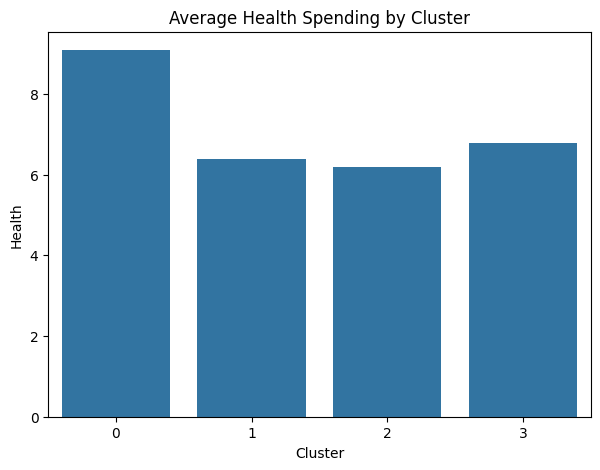

In [33]:
# avg health spending
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Cluster",
    y="health",
    estimator=np.mean,
    errorbar=None
)
plt.title("Average Health Spending by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Health")

plt.show()

## Cluster Interpretation

#### Cluster 0 – Developed Countries
Countries in this cluster have high income, high GDP per capita, high health expenditure, low child mortality, and high life expectancy.

#### Cluster 1 – Underdeveloped Countries
This cluster contains countries with low income and GDP, high child mortality, and relatively low life expectancy.

#### Cluster 2 – Developing Countries
Countries in this cluster exhibit moderate socio-economic indicators and represent developing economies with improving healthcare and economic conditions.

#### Cluster 3 – Wealthy Emerging Economies
This cluster includes countries with exceptionally high income and GDP, excellent healthcare indicators, and very low child mortality.

In [34]:
for cluster in sorted(df["Cluster"].unique()):

    print(f"\nCluster {cluster}")

    print(df[df["Cluster"] == cluster]["country"].values)


Cluster 0
['Australia' 'Austria' 'Bahamas' 'Belgium' 'Brunei' 'Canada' 'Cyprus'
 'Czech Republic' 'Denmark' 'Finland' 'France' 'Germany' 'Greece'
 'Iceland' 'Ireland' 'Israel' 'Italy' 'Japan' 'Kuwait' 'Netherlands'
 'New Zealand' 'Norway' 'Portugal' 'Qatar' 'Slovenia' 'South Korea'
 'Spain' 'Sweden' 'Switzerland' 'United Arab Emirates' 'United Kingdom'
 'United States']

Cluster 1
['Afghanistan' 'Angola' 'Benin' 'Botswana' 'Burkina Faso' 'Burundi'
 'Cameroon' 'Central African Republic' 'Chad' 'Comoros' 'Congo, Dem. Rep.'
 'Congo, Rep.' "Cote d'Ivoire" 'Equatorial Guinea' 'Eritrea' 'Gabon'
 'Gambia' 'Ghana' 'Guinea' 'Guinea-Bissau' 'Haiti' 'Iraq' 'Kenya'
 'Kiribati' 'Lao' 'Lesotho' 'Liberia' 'Madagascar' 'Malawi' 'Mali'
 'Mauritania' 'Mozambique' 'Namibia' 'Niger' 'Nigeria' 'Pakistan' 'Rwanda'
 'Senegal' 'Sierra Leone' 'South Africa' 'Sudan' 'Tanzania' 'Timor-Leste'
 'Togo' 'Uganda' 'Yemen' 'Zambia']

Cluster 2
['Albania' 'Algeria' 'Antigua and Barbuda' 'Argentina' 'Armenia'
 'Azerbaij

# Classification

In [35]:
X = X_scaled.copy()

y = df["Cluster"]

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (133, 9)
Testing Shape : (34, 9)


# Decision Tree Classifier

A Decision Tree is used as a baseline model before applying ensemble learning techniques.

In [37]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
print("Decision Tree Performance")

print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred, average="weighted"))
print("Recall   :", recall_score(y_test, dt_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, dt_pred, average="weighted"))

Decision Tree Performance
Accuracy : 0.9411764705882353
Precision: 0.9179566563467492
Recall   : 0.9411764705882353
F1 Score : 0.9267676767676767


C:\Users\amanp\OneDrive\Desktop\rnn\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    n_estimators=200
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [40]:
print("Random Forest Performance")

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, average="weighted"))
print("Recall   :", recall_score(y_test, rf_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, rf_pred, average="weighted"))

Random Forest Performance
Accuracy : 0.9411764705882353
Precision: 0.9179566563467492
Recall   : 0.9411764705882353
F1 Score : 0.9267676767676767


C:\Users\amanp\OneDrive\Desktop\rnn\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# XGBoost Classifier

XGBoost is a gradient boosting algorithm that builds trees sequentially to improve predictive performance.

In [41]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [42]:
print("XGBoost Performance")

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred, average="weighted"))
print("Recall   :", recall_score(y_test, xgb_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, xgb_pred, average="weighted"))

XGBoost Performance
Accuracy : 0.9411764705882353
Precision: 0.9179566563467492
Recall   : 0.9411764705882353
F1 Score : 0.9267676767676767


C:\Users\amanp\OneDrive\Desktop\rnn\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [43]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, dt_pred, average="weighted"),
        precision_score(y_test, rf_pred, average="weighted"),
        precision_score(y_test, xgb_pred, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, dt_pred, average="weighted"),
        recall_score(y_test, rf_pred, average="weighted"),
        recall_score(y_test, xgb_pred, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, dt_pred, average="weighted"),
        f1_score(y_test, rf_pred, average="weighted"),
        f1_score(y_test, xgb_pred, average="weighted")
    ]
})

results

C:\Users\amanp\OneDrive\Desktop\rnn\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\amanp\OneDrive\Desktop\rnn\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\amanp\OneDrive\Desktop\rnn\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.941176,0.917957,0.941176,0.926768
1,Random Forest,0.941176,0.917957,0.941176,0.926768
2,XGBoost,0.941176,0.917957,0.941176,0.926768


### Observation

- All three classification models achieved an accuracy of approximately 94.1%.
- The Random Forest and XGBoost models performed similarly to the Decision Tree, indicating that the generated clusters are well separated.
- The high performance suggests that the socio-economic indicators provide sufficient information to accurately classify countries into their respective clusters.

# Hyperparameter Tuning

GridSearchCV is used to identify the optimal hyperparameters for the Random Forest classifier, improving the model's predictive performance.

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV Accuracy:")
print(grid.best_score_)

C:\Users\amanp\OneDrive\Desktop\rnn\myenv\lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


In [ ]:
best_rf = grid.best_estimator_

best_pred = best_rf.predict(X_test)

In [ ]:
print("Optimized Random Forest")

print("Accuracy :", accuracy_score(y_test, best_pred))
print("Precision:", precision_score(y_test, best_pred, average="weighted"))
print("Recall   :", recall_score(y_test, best_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, best_pred, average="weighted"))

# Confusion Matrix

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test,
    cmap="Blues"
)
plt.title("Random Forest Confusion Matrix")

plt.show()

# Feature Importance

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    errorbar=None
)

plt.title("Feature Importance")

plt.show()

### Observation

- Child mortality is the most influential feature for predicting country clusters.
- GDP per capita and life expectancy also contribute significantly.
- Inflation and exports have comparatively lower importance.
- These results indicate that economic development and healthcare indicators are the primary factors driving country segmentation.

# DBSCAN Clustering

DBSCAN is applied to identify density-based clusters and detect noise points within the dataset.

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)
db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = db_labels

In [ ]:
print(df["DBSCAN_Cluster"].value_counts().sort_index())

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="DBSCAN_Cluster",
    data=df
)

plt.title("DBSCAN Cluster Distribution")

plt.show()

### Observation

- DBSCAN identified one major cluster containing most countries.
- A small number of countries were classified as noise (-1), representing outliers.
- Compared to K-Means, DBSCAN produced fewer meaningful clusters for this dataset because the socio-economic indicators do not form dense, well-separated groups.

# PCA Visualization

Principal Component Analysis (PCA) is used to reduce the dimensionality of the dataset to two components, enabling visualization of the clusters in a two-dimensional space.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Cluster": df["Cluster"]
})

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=80
)

plt.title("K-Means Clusters (PCA Projection)")

plt.show()

In [ ]:
pca_df["DBSCAN"] = df["DBSCAN_Cluster"]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="DBSCAN",
    palette="Set1",
    s=80
)

plt.title("DBSCAN Clusters (PCA Projection)")

plt.show()

# Business Insights

- Countries were successfully segmented into four distinct groups based on socio-economic indicators.
- Developed countries exhibited high income, high GDP per capita, high healthcare expenditure, and low child mortality.
- Developing countries showed moderate economic and healthcare indicators.
- Underdeveloped countries were characterized by lower income, lower GDP, and higher child mortality.
- Wealthy emerging economies formed a separate cluster due to exceptionally high income and GDP values.
- Child mortality, GDP per capita, and life expectancy were identified as the most influential features for country classification.

# Conclusion

An end-to-end Country Intelligence System was successfully developed using clustering, classification, and ensemble learning techniques.

The project involved:
- Data preprocessing
- Exploratory Data Analysis (EDA)
- K-Means clustering
- DBSCAN clustering
- Decision Tree, Random Forest, and XGBoost classification
- Hyperparameter tuning with GridSearchCV
- Feature importance analysis
- PCA visualization

The results demonstrate that socio-economic indicators can effectively segment countries into meaningful groups, providing valuable insights into economic development and public health.